In [1]:
# 8bit, 4bit 양자화를 지원하는 bitsandbytes 라이브러리 설치
!pip install bitsandbytes

# 분산 학습, 디바이스 자동 설정 등을 도와주는 accelerate 라이브러리 설치
!pip install accelerate

# 설치완료후 런타임 > 세션 재시작

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 11.9 MB/s eta 0:00:00


In [1]:
value = 0.1234567891011121314151617181920212223

In [2]:
!huggingface-cli download openai-community/gpt2 \
    --local-dir ./gpt2 \
    --include "*.safetensors" "*.json" "*.txt"

⚠️  Warning: 'huggingface-cli download' is deprecated. Use 'hf download' instead.
Fetching 14 files:   0% 0/14 [00:00<?, ?it/s]Downloading 'config.json' to 'gpt2/.cache/huggingface/download/8_PA_wEVGiVa2goH2H4KQOQpvVY=.10c66461e4c109db5a2196bff4bb59be30396ed8.incomplete'

merges.txt: 0.00B [00:00, ?B/s]

config.json: 100% 665/665 [00:00<00:00, 5.19MB/s]
Download complete. Moving file to gpt2/config.json


generation_config.json: 100% 124/124 [00:00<00:00, 857kB/s]
Fetching 14 files:   7% 1/14 [00:00<00:02,  5.84it/s]

config.json: 100% 879/879 [00:00<00:00, 7.46MB/s]
Download complete. Moving file to gpt2/generation_config.json
Download complete. Moving file to gpt2/onnx/config.json

merges.txt: 456kB [00:00, 4.34MB/s]
Download complete. Moving file to gpt2/merges.txt

special_tokens_map.json: 100% 99.0/99.0 [00:00<00:00, 979kB/s]
Download complete. Moving file to gpt2/onnx/special_tokens_map.json

generation_config.json: 100% 119/119 [00:00<00:00, 1.28MB/s]
Download complete. Moving f

IEEE-754 float64(=double)로 변환
float64는 53 bit(15~17자리 10진수)의 유효숫자만 보관 할수있음

In [3]:
format(value, '.60f')

'0.123456789101112129891646418400341644883155822753906250000000'

In [4]:
import torch

In [5]:
# 64비트 부동소수점 (float64, double precision) — 약 15~17 자리 십진수 정밀도 제공
# 가장 정확한 표현으로, value 값을 float64로 저장
tensor_fp64 = torch.tensor(value, dtype=torch.float64)

# 32비트 부동소수점 (float32, single precision) — 약 7~9 자리 십진수 정밀도
# float64보다 정밀도는 낮지만 메모리 사용량이 절반
tensor_fp32 = torch.tensor(value, dtype=torch.float32)

# 16비트 부동소수점 (float16, half precision) — 약 3~4 자리 십진수 정밀도
# GPU에서 주로 사용되며, 매우 낮은 정밀도지만 속도와 메모리 효율이 좋음
tensor_fp16 = torch.tensor(value, dtype=torch.float16)

# 16비트 BFloat (bfloat16) — float16과 비슷하지만 정규화 범위는 넓음
# Google TPU 등에서 사용, 정밀도는 낮지만 float32와 유사한 범위 지원
tensor_bf16 = torch.tensor(value, dtype=torch.bfloat16)

# 8비트 부동소수점 (float8 e4m3) — exponent 4비트, mantissa 3비트, fn(denormals 포함)
# 가장 작은 정밀도 포맷 중 하나로, 실험적이고 극도로 메모리 제한된 환경에서 사용
tensor_fp8_e4m3 = torch.tensor(value, dtype=torch.float8_e4m3fn)

# 8비트 부동소수점 (float8 e5m2) — exponent 5비트, mantissa 2비트
# e4m3보다 정규화 범위는 넓지만 유효숫자 비트 수는 적어 정밀도가 낮음
tensor_fp8_e5m2 = torch.tensor(value, dtype=torch.float8_e5m2)


In [6]:
# tensor_fp64: float64는 약 15~17자리 정밀도를 가지므로,
# 소수점 이하 15~17 자릿수를 정확하게 유지한 채 출력됨
print(f"fp64 tensor: {format(tensor_fp64.item(), '.60f')}")

# tensor_fp32: float32는 약 7~9자리까지만 정확하게 표현 가능하므로,
# 그 이후 자릿수는 반올림되거나 오차가 포함된 값으로 보임
print(f"fp32 tensor: {format(tensor_fp32.item(), '.60f')}")

# tensor_fp16: float16은 약 3~4자리까지만 보존 가능,
# 출력의 대부분이 엉뚱하거나 0 근처로 뭉개짐 (정밀도 극히 낮음)
print(f"fp16 tensor: {format(tensor_fp16.item(), '.60f')}")

# tensor_bf16: bfloat16은 float16처럼 16비트지만 지수 비트가 많아 표현 범위가 넓음,
# 다만 정밀도는 낮기 때문에 소수점 이하 초반부터 오차 발생
print(f"bf16 tensor: {format(tensor_bf16.item(), '.60f')}")

# tensor_fp8_e4m3: float8(e4m3)는 exponent 4bit + mantissa 3bit → 정밀도 매우 낮음,
# 표현 가능한 실수 개수가 매우 제한적이라 수치가 완전히 왜곡됨
print(f"fp8(e4m3) tensor: {format(tensor_fp8_e4m3.item(), '.60f')}")

# tensor_fp8_e5m2: float8(e5m2)는 exponent 5bit + mantissa 2bit → 정규화 범위는 넓지만,
# 유효숫자 비트 수가 적어 정밀도는 더 낮음 → 값 자체가 매우 부정확
print(f"fp8(e5m2) tensor: {format(tensor_fp8_e5m2.item(), '.60f')}")


fp64 tensor: 0.123456789101112129891646418400341644883155822753906250000000
fp32 tensor: 0.123456791043281555175781250000000000000000000000000000000000
fp16 tensor: 0.123474121093750000000000000000000000000000000000000000000000
bf16 tensor: 0.123535156250000000000000000000000000000000000000000000000000
fp8(e4m3) tensor: 0.125000000000000000000000000000000000000000000000000000000000
fp8(e5m2) tensor: 0.125000000000000000000000000000000000000000000000000000000000


In [7]:
import torch

def absmax_quantize(X):
    # 1. 스케일 계산 (scale = 127 / max(abs(X)))
    # - int8은 표현 가능한 정수 범위가 [-128, 127]이므로
    # - 입력 텐서의 최대 절댓값을 127에 맞춰 스케일링
    # - 양자화는 대칭적 방식으로 수행됨
    scale = 127 / torch.max(torch.abs(X))

    # 2. 양자화 (Quantization)
    # - 실수 텐서 X를 정수 범위로 스케일링한 뒤, 반올림
    # - 이 결과는 float지만 정수형 범위의 값들 (예: 0.4 → 0, 1.8 → 2)
    X_quant = (scale * X).round()

    # 3. 복원 (Dequantization)
    # - 양자화된 정수값을 다시 실수값으로 환산
    # - 주의: 이 과정에서 원래의 X와는 다소 차이가 있을 수 있음 (양자화 오차)
    X_dequant = X_quant / scale

    # 4. 정수 타입으로 반환 (int8로 형변환)
    return X_quant.to(torch.int8), X_dequant


In [8]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

# 재현 가능성을 위해 랜덤 시드 고정 (모델 초기화 또는 샘플링 등에 영향)
torch.manual_seed(0)

# 모델 연산에 사용할 장치 설정: 'cuda' → GPU 사용
device = 'cuda'

# Hugging Face Hub에서 사전 학습된 causal LM (GPT-2) 모델과 토크나이저 불러오기
model_id = '/content/gpt2'

# 모델 로드 및 지정한 장치로 이동 (GPU)
model = AutoModelForCausalLM.from_pretrained(model_id).to(device)

# 토크나이저 로드 (입력 텍스트를 토큰으로 인코딩/디코딩)
tokenizer = AutoTokenizer.from_pretrained(model_id)

# 모델이 사용하는 총 메모리 (바이트 단위) 출력
# GPU 메모리 기준이며, 파라미터 가중치 기준의 raw 메모리 사용량
print(f"Model size: {model.get_memory_footprint():,} bytes")

Model size: 510,342,192 bytes


In [9]:
print(model)  # 모델 전체 구조 (계층별 layer 구성)를 출력

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)


In [10]:
# 첫 번째 Transformer 블록의 self-attention에서 c_attn (query/key/value projection) 가중치 추출
weights = model.transformer.h[0].attn.c_attn.weight.data

print("Original weights:")  # 원래의 float32 가중치 행렬 출력
print(weights)

# absmax 양자화를 적용하여 int8 범위로 정규화된 양자화된 가중치 생성
weights_abs_quant, _ = absmax_quantize(weights)

print("\nAbsmax quantized weights:")  # 양자화된 int8 가중치 행렬 출력
print(weights_abs_quant)


Original weights:
tensor([[-0.4738, -0.2614, -0.0978,  ...,  0.0513, -0.0584,  0.0250],
        [ 0.0874,  0.1473,  0.2387,  ..., -0.0525, -0.0113, -0.0156],
        [ 0.0039,  0.0695,  0.3668,  ...,  0.1143,  0.0363, -0.0318],
        ...,
        [-0.2592, -0.0164,  0.1991,  ...,  0.0095, -0.0516,  0.0319],
        [ 0.1517,  0.2170,  0.1043,  ...,  0.0293, -0.0429, -0.0475],
        [-0.4100, -0.1924, -0.2400,  ..., -0.0046,  0.0070,  0.0198]],
       device='cuda:0')

Absmax quantized weights:
tensor([[-21, -12,  -4,  ...,   2,  -3,   1],
        [  4,   7,  11,  ...,  -2,  -1,  -1],
        [  0,   3,  16,  ...,   5,   2,  -1],
        ...,
        [-12,  -1,   9,  ...,   0,  -2,   1],
        [  7,  10,   5,  ...,   1,  -2,  -2],
        [-18,  -9, -11,  ...,   0,   0,   1]], device='cuda:0',
       dtype=torch.int8)


In [11]:
import numpy as np
from copy import deepcopy

# 모델의 원본 가중치를 보존 (추후 비교나 복원용)
weights = [param.data.clone() for param in model.parameters()]

# 모델을 복사하여 양자화 전용 사본 생성
model_abs = deepcopy(model)

# 모든 가중치에 대해 absmax 양자화를 적용
weights_abs = []
for param in model_abs.parameters():
    _, dequantized = absmax_quantize(param.data)  # 양자화 후 복원된 실수 값 사용
    param.data = dequantized  # 복원된 값을 모델 파라미터에 덮어쓰기
    weights_abs.append(dequantized)  # 결과 저장


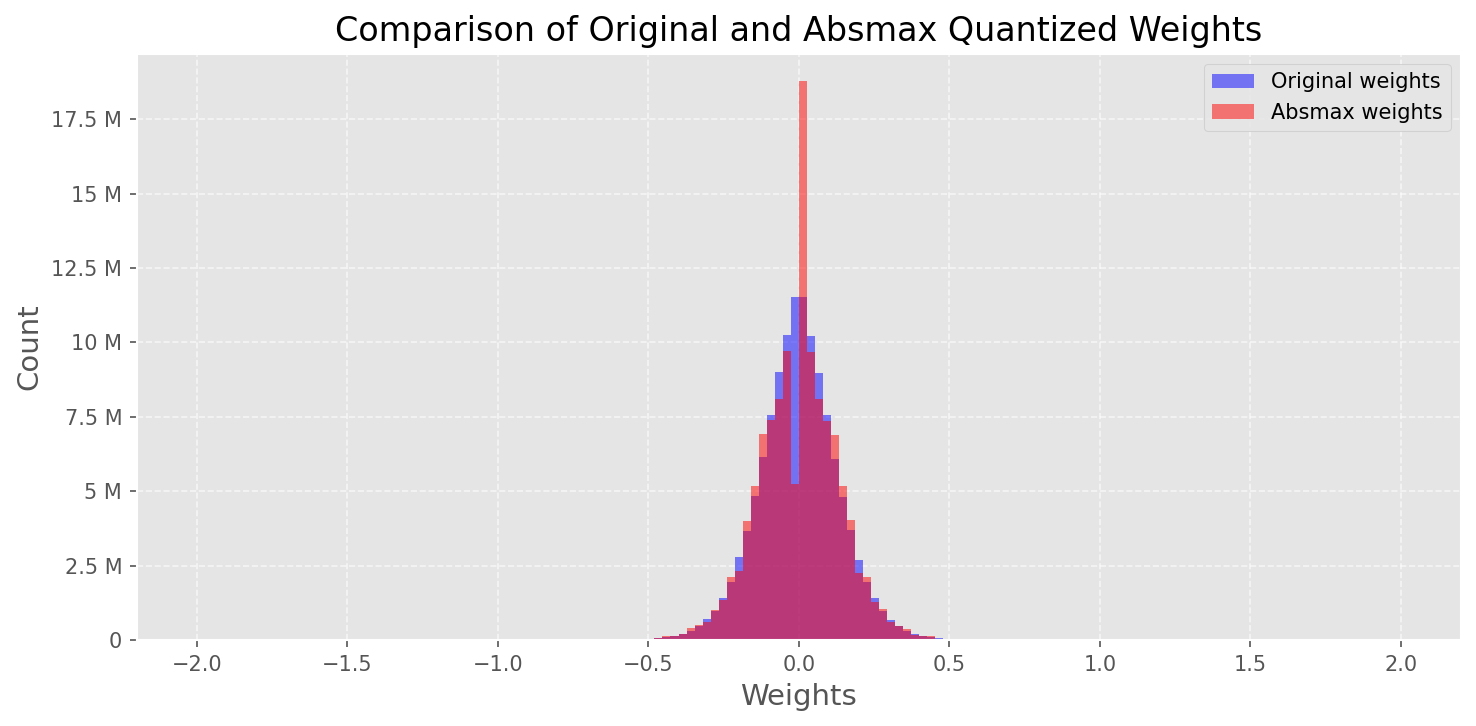

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 모든 가중치 텐서를 평탄화 후 하나의 배열로 결합 (시각화용)
weights = np.concatenate([t.cpu().numpy().flatten() for t in weights])
weights_abs = np.concatenate([t.cpu().numpy().flatten() for t in weights_abs])

# 배경 스타일 설정
plt.style.use('ggplot')

# 그래프 크기 및 해상도 설정
fig, ax = plt.subplots(figsize=(10,5), dpi=150)

# 원본 가중치와 absmax 양자화된 가중치의 히스토그램을 겹쳐서 시각화
# bins개수만큼 wieghts들을 카운팅하여 range -2, 2 구간으로 범위 제한
ax.hist(weights, bins=150, alpha=0.5, label='Original weights', color='blue', range=(-2, 2))
ax.hist(weights_abs, bins=150, alpha=0.5, label='Absmax weights', color='red', range=(-2, 2))

# 범례 추가
ax.legend()

# 그리드 추가
ax.grid(True, linestyle='--', alpha=0.6)

# 제목 및 축 레이블 설정
ax.set_title('Comparison of Original and Absmax Quantized Weights', fontsize=16)
ax.set_xlabel('Weights', fontsize=14)
ax.set_ylabel('Count', fontsize=14)

# y축 눈금을 사람이 보기 좋게 표시 (예: 1K, 10K 등)
ax.yaxis.set_major_formatter(ticker.EngFormatter())

# 기본 폰트 크기 조정
plt.rc('font', size=12)

# 여백 자동 조정
plt.tight_layout()

# 그래프 표시
plt.show()


In [13]:
# 텍스트를 생성하는 함수 정의
def generate_text(model, input_text, max_length=50):
    # 입력 텍스트를 토큰화하여 텐서로 변환하고 지정한 디바이스로 이동
    input_ids = tokenizer.encode(input_text, return_tensors='pt').to(device)

    # 주어진 모델로 텍스트 생성 (샘플링 사용, top-k 제한)
    output = model.generate(
        inputs=input_ids,
        max_length=max_length,                        # 최대 생성 길이
        do_sample=True,                               # 확률적 샘플링 사용
        top_k=30,                                     # 확률 상위 30개에서 선택
        pad_token_id=tokenizer.eos_token_id,          # padding을 위해 eos 토큰 사용
        attention_mask=input_ids.new_ones(input_ids.shape)  # 모든 토큰에 attention 적용
    )

    # 생성된 토큰 시퀀스를 문자열로 디코딩하여 반환 (특수 토큰 제외)
    return tokenizer.decode(output[0], skip_special_tokens=True)

# 원본 모델과 absmax 양자화 모델을 사용하여 텍스트 생성
original_text = generate_text(model, "I have a dream")
absmax_text   = generate_text(model_abs, "I have a dream")

# 생성된 결과 출력
print(f"Original model:\n{original_text}")
print("-" * 50)
print(f"Absmax model:\n{absmax_text}")


Original model:
I have a dream. I don't know what will come of it, but I am going to have to look for something that will be right. I haven't thought about it for a long time, but I have to try to get that thing
--------------------------------------------------
Absmax model:
I have a dream job.

If you can talk about your work and what you believe, then come on! I'm gonna love you!


* perplexity는 모델이 다음 단어를 얼마나 "혼란스러워하는지"를  나타내는 지표입니다.

* 값이 낮을수록 더 정확히 예측한다는 뜻입니다.

* 예: perplexity가 5라면, 모델은 다음 단어를 평균적으로 5개의 선택지 중에서 고르는 정도의 불확실성을 가진다는 의미입니다.

I have a dream

이 경우 모델은 다음처럼 예측하게 됩니다:

* "I"를 보고 → "have"를 예측

* "I have"를 보고 → "a"를 예측

* "I have a"를 보고 → "dream"을 예측

* "I have a dream"을 보고 → 종료 토큰 (예: ``)을 예측

즉, 각 시점에서 모델이 정답 토큰을 얼마나 잘 예측했는지를 계산한 평균값이 바로 loss입니다.



In [14]:
# 주어진 모델과 텍스트에 대해 perplexity(혼란도)를 계산하는 함수 정의
def calculate_perplexity(model, text):
    # 텍스트를 토크나이즈하여 입력 텐서 생성
    encodings = tokenizer(text, return_tensors='pt').to(device)

    # 입력 텐서를 정의
    input_ids = encodings.input_ids
    target_ids = input_ids.clone()  # 라벨로 사용할 복사본

    # 모델 추론 (gradient 계산 없이)
    with torch.no_grad():
        outputs = model(input_ids, labels=target_ids)  # 입력과 타겟을 동일하게 설정

    # 모델 출력에서 loss (negative log-likelihood) 추출
    neg_log_likelihood = outputs.loss

    # perplexity = e^(loss)
    ppl = torch.exp(neg_log_likelihood)

    return ppl

# 원본 모델과 양자화된 모델의 perplexity 계산
ppl     = calculate_perplexity(model, original_text)
ppl_abs = calculate_perplexity(model_abs, absmax_text)

# 결과 출력
print(f"Original perplexity: {ppl.item():.2f}")
print(f"Absmax perplexity:   {ppl_abs.item():.2f}")


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Original perplexity: 7.94
Absmax perplexity:   21.84


In [15]:
# 양자화된 모델(model_abs)의 모든 파라미터 이름(name)과 데이터 타입(dtype)을 출력
for name, param in model_abs.named_parameters():
    print(f"{name:<60} | {str(param.dtype):>10}")  # 이름은 왼쪽 정렬, dtype은 오른쪽 정렬로 출력

transformer.wte.weight                                       | torch.float32
transformer.wpe.weight                                       | torch.float32
transformer.h.0.ln_1.weight                                  | torch.float32
transformer.h.0.ln_1.bias                                    | torch.float32
transformer.h.0.attn.c_attn.weight                           | torch.float32
transformer.h.0.attn.c_attn.bias                             | torch.float32
transformer.h.0.attn.c_proj.weight                           | torch.float32
transformer.h.0.attn.c_proj.bias                             | torch.float32
transformer.h.0.ln_2.weight                                  | torch.float32
transformer.h.0.ln_2.bias                                    | torch.float32
transformer.h.0.mlp.c_fc.weight                              | torch.float32
transformer.h.0.mlp.c_fc.bias                                | torch.float32
transformer.h.0.mlp.c_proj.weight                            | torch.float32

In [16]:
# device 설정 (사용 가능 시 GPU, 아니면 CPU 사용)
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = 'cuda'  # 여기서는 강제로 GPU 지정

from transformers import AutoModelForCausalLM, BitsAndBytesConfig

quant_config = BitsAndBytesConfig(load_in_8bit=True)


# 8bit 양자화된 모델을 로드
model_int8 = AutoModelForCausalLM.from_pretrained(
    model_id,               # 사용할 모델 ID (예: "gpt2")
    device_map='auto',      # 자동으로 GPU 또는 CPU에 모델 레이어 배치
    quantization_config=quant_config       # bitsandbytes를 이용한 8bit 양자화 활성화
)

# 모델의 GPU 메모리 사용량 출력 (양자화된 상태 기준)
print(f"Model size: {model_int8.get_memory_footprint():,} bytes")


Model size: 176,527,896 bytes


In [17]:
import numpy as np

In [18]:
import bitsandbytes as bnb
for name, module in model_int8.named_modules():
    if isinstance(module, bnb.nn.Linear8bitLt):
        print(f"{name} is 8-bit quantized")

transformer.h.0.attn.c_attn is 8-bit quantized
transformer.h.0.attn.c_proj is 8-bit quantized
transformer.h.0.mlp.c_fc is 8-bit quantized
transformer.h.0.mlp.c_proj is 8-bit quantized
transformer.h.1.attn.c_attn is 8-bit quantized
transformer.h.1.attn.c_proj is 8-bit quantized
transformer.h.1.mlp.c_fc is 8-bit quantized
transformer.h.1.mlp.c_proj is 8-bit quantized
transformer.h.2.attn.c_attn is 8-bit quantized
transformer.h.2.attn.c_proj is 8-bit quantized
transformer.h.2.mlp.c_fc is 8-bit quantized
transformer.h.2.mlp.c_proj is 8-bit quantized
transformer.h.3.attn.c_attn is 8-bit quantized
transformer.h.3.attn.c_proj is 8-bit quantized
transformer.h.3.mlp.c_fc is 8-bit quantized
transformer.h.3.mlp.c_proj is 8-bit quantized
transformer.h.4.attn.c_attn is 8-bit quantized
transformer.h.4.attn.c_proj is 8-bit quantized
transformer.h.4.mlp.c_fc is 8-bit quantized
transformer.h.4.mlp.c_proj is 8-bit quantized
transformer.h.5.attn.c_attn is 8-bit quantized
transformer.h.5.attn.c_proj is 8-

In [19]:
weights_int82 = [param.data.clone() for param in model_int8.parameters()]

In [20]:
for name, param in model_int8.named_parameters():
    print(f"{name:<60} | {str(param.dtype):>10}")

transformer.wte.weight                                       | torch.float16
transformer.wpe.weight                                       | torch.float16
transformer.h.0.ln_1.weight                                  | torch.float16
transformer.h.0.ln_1.bias                                    | torch.float16
transformer.h.0.attn.c_attn.weight                           | torch.int8
transformer.h.0.attn.c_attn.bias                             | torch.float16
transformer.h.0.attn.c_proj.weight                           | torch.int8
transformer.h.0.attn.c_proj.bias                             | torch.float16
transformer.h.0.ln_2.weight                                  | torch.float16
transformer.h.0.ln_2.bias                                    | torch.float16
transformer.h.0.mlp.c_fc.weight                              | torch.int8
transformer.h.0.mlp.c_fc.bias                                | torch.float16
transformer.h.0.mlp.c_proj.weight                            | torch.int8
transformer

In [21]:
import bitsandbytes as bnb

# 디퀀타이즈된 float 파라미터들을 저장할 리스트 초기화
weights_fp = []

for param in model_int8.parameters():
    # bitsandbytes의 8bit 양자화 파라미터인 경우, dequantize()로 복원
    if hasattr(param, 'dequantize'):
        deq = param.dequantize().clone()  # 복원된 float32 텐서 복사
    else:
        deq = param.data.clone()          # 이미 float일 경우 그대로 복사

    weights_fp.append(deq)  # 리스트에 추가


In [22]:
import numpy as np

# 안전하게 float 파라미터만 추출 + 1D로 펼쳐서 concat
weight_arrays = []

for t in weights_fp:
    try:
        # 텐서를 numpy 배열로 변환하고 1D로 평탄화
        arr = t.detach().cpu().numpy().flatten()
        weight_arrays.append(arr)
    except Exception as e:
        # 변환 중 에러가 발생하면 해당 텐서는 건너뜀
        print(f"Skipping tensor due to error: {e}")
        continue

# 모든 텐서를 하나의 1D 배열로 연결
weights_flat = np.concatenate(weight_arrays)
print("Total flattened weight shape:", weights_flat.shape)


Total flattened weight shape: (124439808,)


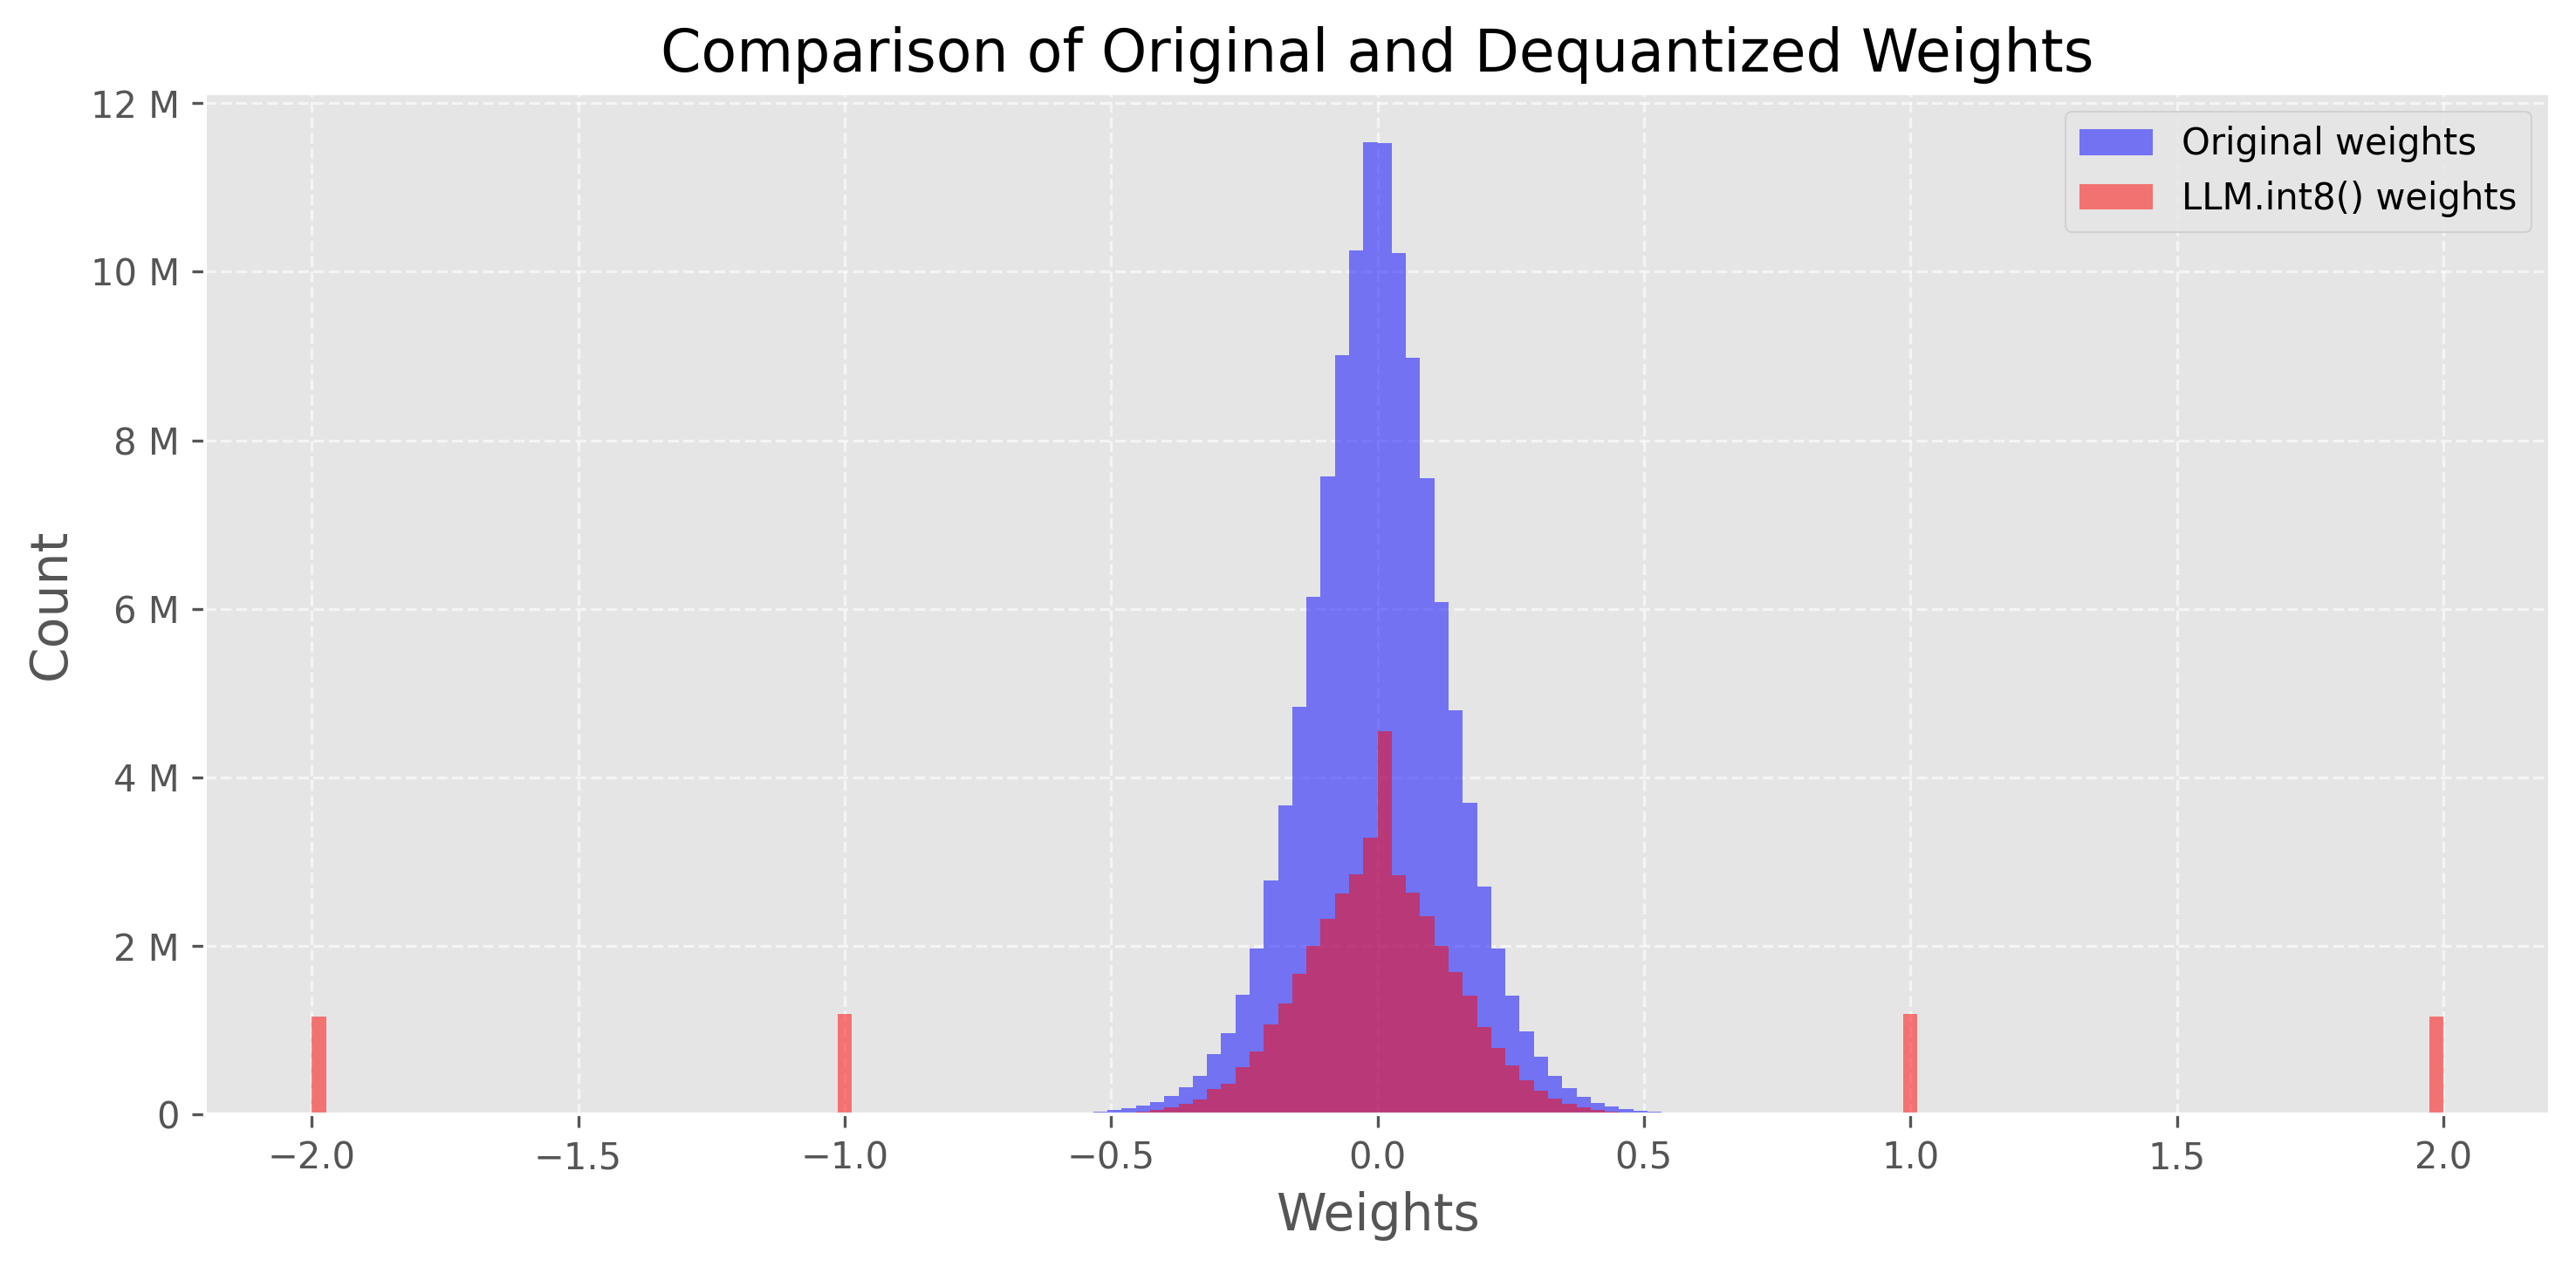

In [23]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Flatten weight tensors (LLM.int8() 모델에서 추출한 디퀀타이즈된 가중치 사용)
# weights_int8 = weights_fp  또는 weights_flat 사용 가능
weights_int8 = weights_flat  # 1D numpy 배열로 평탄화된 버전

# 시각화 스타일 설정 (ggplot 테마)
plt.style.use('ggplot')

# 시각화 캔버스 및 축 생성
fig, ax = plt.subplots(figsize=(10, 5), dpi=300)

# 원본 float32 가중치 히스토그램 시각화
ax.hist(weights, bins=150, alpha=0.5, label='Original weights',
        color='blue', range=(-2, 2))

# LLM.int8() 디퀀타이즈된 가중치 히스토그램 시각화
ax.hist(weights_int8, bins=150, alpha=0.5, label='LLM.int8() weights',
        color='red', range=(-2, 2))

# 격자 추가
ax.grid(True, linestyle='--', alpha=0.6)

# 범례 추가
ax.legend()

# 제목 및 축 레이블 추가
ax.set_title('Comparison of Original and Dequantized Weights', fontsize=16)
ax.set_xlabel('Weights', fontsize=14)
ax.set_ylabel('Count', fontsize=14)

# y축 숫자 표현을 사람이 읽기 쉽게 (e.g. 1K, 10K 등)
plt.gca().yaxis.set_major_formatter(ticker.EngFormatter())

# 전체 폰트 크기 조정
plt.rc('font', size=12)

# 여백 자동 조정
plt.tight_layout()

# 그래프 표시
plt.show()


* 블록 단위(block-wise) 양자화: 전체 weight가 아닌 작은 블록마다 별도로 quantize

* 비선형 스케일링 + zero-point 보정 적용

* 정밀도보다 메모리 효율을 우선시함

* 일부 값은 0, ±1, ±2, ±127 같은 특정 값으로 강하게 뭉칩니다 (→ 히스토그램 끝에 spike가 생기는 이유)

* 결과적으로 dequantize()를 하더라도 원래의 연속적 분포를 되찾을 수 없습니다.

In [24]:
# Generate text with quantized model
text_int8 = generate_text(model_int8, "I have a dream")

print(f"Original model:\n{original_text}")
print("-" * 50)
print(f"LLM.int8() model:\n{text_int8}")

Original model:
I have a dream. I don't know what will come of it, but I am going to have to look for something that will be right. I haven't thought about it for a long time, but I have to try to get that thing
--------------------------------------------------
LLM.int8() model:
I have a dream.

I am a human being, but in my dream I am a person.

Life does not have to be good.

I am a human being, but in my dream I am a person.



In [ ]:
print(f"Perplexity (original):   {ppl.item():.2f}")

ppl_int = calculate_perplexity(model_int8, text_int8)
print(f"Perplexity (LLM.int8()): {ppl_int.item():.2f}")

Perplexity (original):   7.94
Perplexity (LLM.int8()): 10.60
